# Model-dependent analysis 

We have some data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import _fig_params

In [2]:
x = np.linspace(0, 10, 5)
y = np.array([2.01,  4.68,  9.56, 10.62, 15.54])
yerr = np.ones_like(y) * 1.5

In [3]:
def log_likelihood(theta, x, y, yerr):
    m, b = theta
    model = m * x + b
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

In [4]:
from scipy.stats import multivariate_normal

In [5]:
def log_prior(theta):
    m, b = theta
    p = multivariate_normal(mean=[1.1, 2.5], cov=[[0.1, 0], [0, 0.5]])
    return p.logpdf([m, b])

In [14]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [25]:
import emcee

pos = [1.25, 2.38] + 1e-4 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:05<00:00, 837.11it/s]


In [26]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 2)


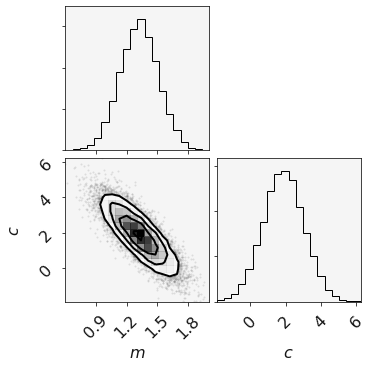

In [9]:
import corner

fig = corner.corner(
    flat_samples, labels=['$m$', '$c$']
)
plt.savefig('figures/likelihood.png', dpi=600)

In [10]:
pos = [1.25, 2.38] + 1e-4 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prior)
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:50<00:00, 98.29it/s] 


In [11]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 2)


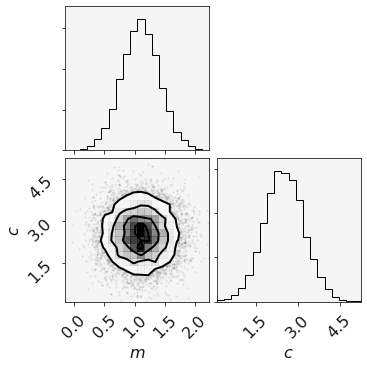

In [12]:
fig = corner.corner(
    flat_samples, labels=['$m$', '$c$']
)
plt.savefig('figures/priors.png', dpi=600)

In [15]:
pos = [1.25, 2.38] + 1e-4 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:52<00:00, 95.15it/s] 


In [16]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

(10432, 2)


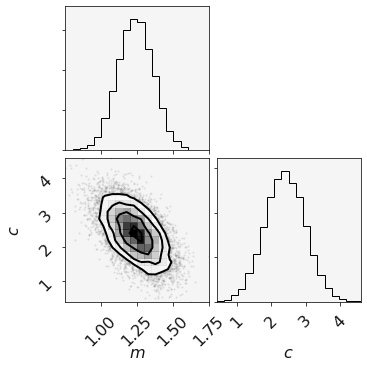

In [24]:
fig = corner.corner(
    flat_samples, labels=['$m$', '$c$']
)
plt.savefig('figures/posterior.png', dpi=600)

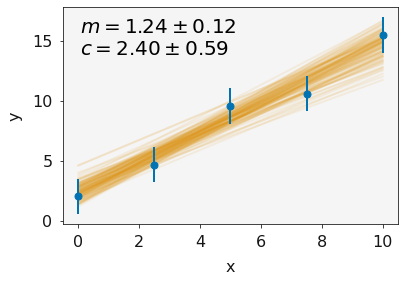

In [18]:
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr, marker='o', ls='', zorder=10)
choice = np.random.randint(0, flat_samples.shape[0], size=100)
for i in choice:
    ax.plot(x, flat_samples[i, 0] * x + flat_samples[i, 1], alpha=0.1, color=_fig_params.colors[1])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.text(0.05, 0.95, '$m={0:.2f}\pm{2:.2f}$\n$c={1:.2f}\pm{3:.2f}$'.format(*flat_samples.mean(axis=0), *flat_samples.std(axis=0)), horizontalalignment='left',
        verticalalignment='top', transform=ax.transAxes)
plt.savefig('figures/bayes_line.png', dpi=600)